<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/main/Bildextraktion_alleFr%C3%BCchteBilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laden der Daten und vorbereiten**

Hier wurde das Modell (mit der selben Architektur wie bei anderen Trainings) mit den ursprünglichen Trainingsdaten trainiert. Allerdings haben wir bei der Validierung also beim Testing 20 neue banane_extra Bilder verwendet, die zwar ein vergleichbaren Untergrund haben von der Farbe aber andere Textur und Belichtung plus andere Banane.

In [1]:
# ============================================
# BLOCK 1 — Drive mount + Pfade + Imports
# (Quelle: fruits_baum_split/{train,test} + XLSX)
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import os, random, shutil, json, hashlib
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/fruits_baum_split")
TRAIN_DIR = BASE/"train"
TEST_DIR  = BASE/"test"
SPLIT_XLSX = BASE/"train_test_split.xlsx"

assert TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()), "TRAIN_DIR leer/nicht vorhanden."
assert TEST_DIR.exists()  and any(TEST_DIR.iterdir()),  "TEST_DIR leer/nicht vorhanden."
assert SPLIT_XLSX.exists(), "train_test_split.xlsx nicht gefunden."
print("✅ Struktur gefunden:", BASE)
print("   ↳", TRAIN_DIR)
print("   ↳", TEST_DIR)
print("   ↳", SPLIT_XLSX)


Mounted at /content/drive
✅ Struktur gefunden: /content/drive/MyDrive/fruits_baum_split
   ↳ /content/drive/MyDrive/fruits_baum_split/train
   ↳ /content/drive/MyDrive/fruits_baum_split/test
   ↳ /content/drive/MyDrive/fruits_baum_split/train_test_split.xlsx


In [2]:
# ============================================
# BLOCK 2 — Mapping einlesen (Professor: Dokumentation)
# ============================================

df_split = pd.read_excel(SPLIT_XLSX)
print("🧾 Split-Mapping (Kopf):")
display(df_split.head(8))

print("\nTrain/Test-Verhältnis (aus Mapping):")
display(df_split.groupby(["Klasse","TrainOrTest"]).size().unstack(fill_value=0))


🧾 Split-Mapping (Kopf):


,Dateiname,Quelle,Klasse,TrainOrTest
0,avo_bio_015.jpg,/content/drive/MyDrive/fruits_baum/train/avo_b...,avo_bio,train
1,banane_extra_019.jpg,/content/drive/MyDrive/fruits_baum/train/banan...,banane_extra,train
2,citron_normal_001.jpg,/content/drive/MyDrive/fruits_baum/train/citro...,citron_normal,train
3,mango_normal_018.jpg,/content/drive/MyDrive/fruits_baum/train/mango...,mango_normal,train
4,citron_normal_040.jpg,/content/drive/MyDrive/fruits_baum/train/citro...,citron_normal,train
5,avo_normal_007.jpg,/content/drive/MyDrive/fruits_baum/train/avo_n...,avo_normal,train
6,banane_extra_028.jpg,/content/drive/MyDrive/fruits_baum/train/banan...,banane_extra,train
7,banane_extra_005.jpg,/content/drive/MyDrive/fruits_baum/train/banan...,banane_extra,train



Train/Test-Verhältnis (aus Mapping):


TrainOrTest,test,train
Klasse,,
avo_bio,3,12
avo_normal,3,11
banane_extra,9,37
banane_normal,3,11
citron_bio,3,12
citron_normal,10,42
mango_extra,5,21
mango_normal,4,16
süssK_bio,3,13


In [3]:
# ============================================
# BLOCK 3 — Klassen-Counts + Duplikat-Check (Name)
# (Professor: saubere Trennung sicherstellen)
# ============================================

def class_counts(root: Path):
    return pd.Series({p.name: len([f for f in p.iterdir() if f.is_file()])
                      for p in sorted(root.iterdir()) if p.is_dir()}).sort_index()

print("📦 Klassenverteilung — TRAIN:")
display(class_counts(TRAIN_DIR))
print("\n📦 Klassenverteilung — TEST:")
display(class_counts(TEST_DIR))

train_names = {f.name for f in TRAIN_DIR.rglob("*/*") if f.is_file()}
test_names  = {f.name for f in TEST_DIR.rglob("*/*") if f.is_file()}
intersect = train_names.intersection(test_names)
print(f"\n🧪 Duplikate (Dateiname) train∩test: {len(intersect)}")
assert len(intersect) == 0, "Dateiname sowohl in train als auch test → bitte Split prüfen."


📦 Klassenverteilung — TRAIN:


,0
avo_bio,12
avo_normal,11
banane_extra,37
banane_normal,11
citron_bio,12
citron_normal,42
mango_extra,21
mango_normal,16
süssK_bio,13
süssK_normal,25



📦 Klassenverteilung — TEST:


,0
avo_bio,3
avo_normal,3
banane_extra,9
banane_normal,3
citron_bio,3
citron_normal,10
mango_extra,5
mango_normal,4
süssK_bio,3
süssK_normal,7



🧪 Duplikate (Dateiname) train∩test: 0


In [5]:
# ============================================
# BLOCK 3b — (Optional) Hash-Check auf echte Inhaltsduplikate
# (Professor macht's nicht explizit; hier ergänzt)
# ============================================

DO_HASH_CHECK = False  # bei Bedarf True setzen (langsamer)

def md5sum(path: Path, chunk=1<<20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while (b := f.read(chunk)):
            h.update(b)
    return h.hexdigest()

if DO_HASH_CHECK:
    def hash_index(root: Path):
        idx = {}
        for f in sorted([p for p in root.rglob("*") if p.is_file()]):
            idx.setdefault(md5sum(f), []).append(f)
        return idx

    train_hash = hash_index(TRAIN_DIR)
    test_hash  = hash_index(TEST_DIR)
    dupe_hashes = set(train_hash).intersection(test_hash)
    print(f"🧪 Duplikate (Inhalt/MD5) train∩test: {len(dupe_hashes)}")
    assert len(dupe_hashes) == 0, "Inhaltsgleiche Dateien in train & test gefunden."


In [6]:
# ============================================
# BLOCK 4 — Datasets laden (Train=80/20 Val, Test separat)
# (Professor-Flow; deine Bildgröße/Batch/Seed)
# ============================================

import tensorflow as tf

image_size = (128, 128)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=seed,
    image_size=image_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=seed,
    image_size=image_size, batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=image_size, batch_size=batch_size
)

class_names = train_ds.class_names
print("🔤 Klassen:", class_names)

# Performance (Cache/Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100, seed=seed).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 200 files belonging to 10 classes.
Using 160 files for training.
Found 200 files belonging to 10 classes.
Using 40 files for validation.
Found 50 files belonging to 10 classes.
🔤 Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


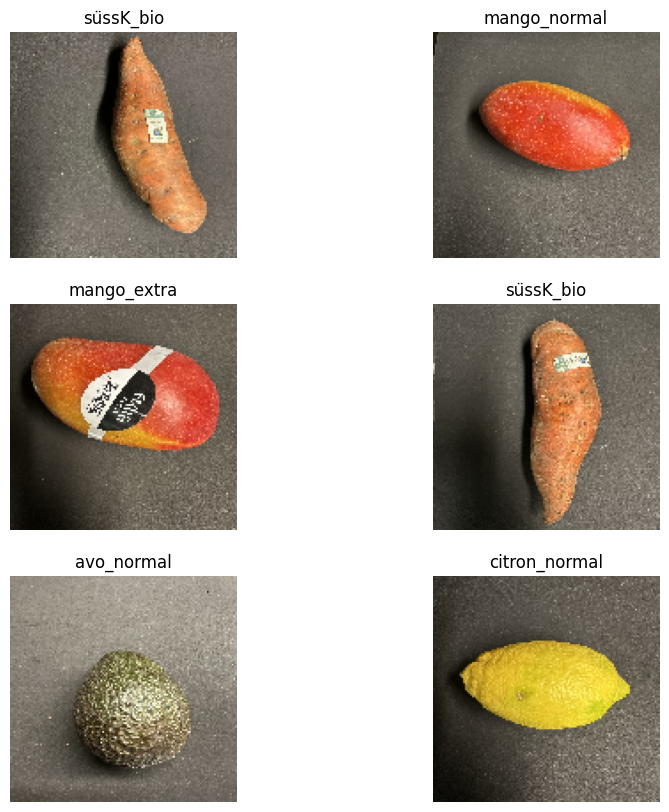

In [7]:
# ============================================
# BLOCK 5 — Sichtprüfung (Sample-Bilder)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [8]:
# ============================================
# BLOCK 6 — Modell (deine Architektur & Parameter beibehalten)
# ============================================

from tensorflow.keras import layers

num_classes = len(class_names)
color_image_size = (*image_size, 3)

def make_model():
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    x = layers.Rescaling(1./255)(img_inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='Ausgabe')(x)
    return tf.keras.Model(inputs=img_inputs, outputs=outputs, name='FruitClassifier')

model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ausgabe (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ============================================
# BLOCK 7 — Kompilieren + Training (EarlyStopping)
# ============================================

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"\n📈 Validation Accuracy: {val_acc:.2%}")


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.7384 - loss: 0.6857 - val_accuracy: 0.8500 - val_loss: 0.4053
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8027 - loss: 0.5009 - val_accuracy: 0.5750 - val_loss: 0.8199
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8523 - loss: 0.3893 - val_accuracy: 0.9000 - val_loss: 0.3625
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8629 - loss: 0.3845 - val_accuracy: 0.8500 - val_loss: 0.3576
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9076 - loss: 0.3012 - val_accuracy: 0.7000 - val_loss: 0.6021
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8753 - loss: 0.3752 - val_accuracy: 0.8500 - val_loss: 0.3375
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8728 - loss: 0.2988 - val_accuracy: 0.8000 - val_loss: 0.4815
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8837 - loss: 0.2775 - val_accuracy: 0.8000 - val_loss: 0.3075
Epoch

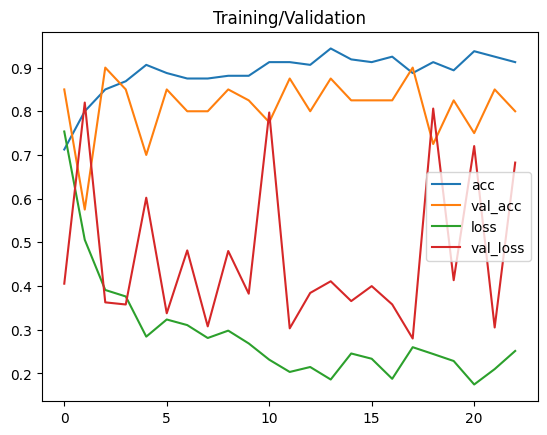

In [15]:
# ============================================
# BLOCK 8 — Trainingskurven
# ============================================

plt.figure()
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training/Validation")
plt.show()


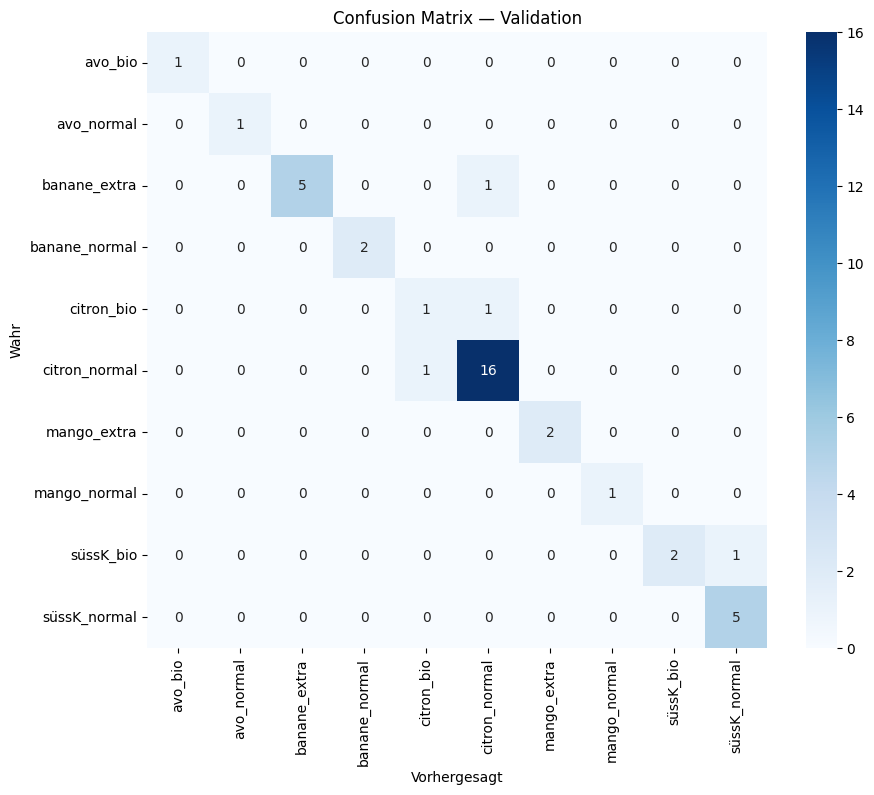


📊 Klassifikationsreport (Validation):
               precision    recall  f1-score   support

      avo_bio       1.00      1.00      1.00         1
   avo_normal       1.00      1.00      1.00         1
 banane_extra       1.00      0.83      0.91         6
banane_normal       1.00      1.00      1.00         2
   citron_bio       0.50      0.50      0.50         2
citron_normal       0.89      0.94      0.91        17
  mango_extra       1.00      1.00      1.00         2
 mango_normal       1.00      1.00      1.00         1
   süssK_bio       1.00      0.67      0.80         3
süssK_normal       0.83      1.00      0.91         5

     accuracy                           0.90        40
    macro avg       0.92      0.89      0.90        40
 weighted avg       0.91      0.90      0.90        40



In [16]:
# ============================================
# BLOCK 9 — Fehleranalyse (Validation) — Confusion + Report
# ============================================

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for xb, yb in val_ds:
    pr = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy())
    y_pred.extend(np.argmax(pr, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
cm_val = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Vorhergesagt")
plt.ylabel("Wahr")
plt.title("Confusion Matrix — Validation")
plt.show()

print("\n📊 Klassifikationsreport (Validation):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


In [17]:
# ============================================
# BLOCK 10 — Finale Test-Evaluation (Professor-Style)
# (Confusion + PR/ROC auf TEST)
# ============================================

import scikitplot as skplt
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ TEST Accuracy: {test_acc:.2%}")

y_true_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob_test = model.predict(test_ds, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)

print("\n📊 Klassifikationsreport (TEST):")
print(classification_report([class_names[i] for i in y_true_test],
                            [class_names[i] for i in y_pred_test],
                            zero_division=0))

ax = skplt.metrics.plot_confusion_matrix(
    [class_names[i] for i in y_true_test],
    [class_names[i] for i in y_pred_test],
    normalize=True, x_tick_rotation=45, figsize=(8,6)
)
ax.set_title("Confusion Matrix — TEST (normalized)")

ax = skplt.metrics.plot_precision_recall([class_names[i] for i in y_true_test],
                                         y_prob_test, figsize=(8,6))
ax.legend(bbox_to_anchor=(1.1, 1.05))
ax.set_title("Precision-Recall — TEST")

ax = skplt.metrics.plot_roc([class_names[i] for i in y_true_test],
                            y_prob_test, figsize=(8,6))
ax.legend(bbox_to_anchor=(1.1, 1.05))
ax.set_title("ROC — TEST")


ModuleNotFoundError: No module named 'scikitplot'

In [ ]:
# ============================================
# BLOCK 11 — Modell + Label-Mapping speichern (Drive)
# (Professor speichert Modell; hier zusätzlich Klassen-JSON)
# ============================================

MODEL_DIR = BASE/"model_out"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

keras_path = MODEL_DIR/"model_fruits.keras"
model.save(keras_path)
print("💾 Modell gespeichert:", keras_path)

labels_path = MODEL_DIR/"class_names.json"
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print("💾 Klassen gespeichert:", labels_path)

# Reload-Test
_ = tf.keras.models.load_model(keras_path)
print("🔁 Reload OK.")


In [ ]:
# ============================================
# BLOCK 12 — (Optional) OOD/Session-Shift Test (falls separater Ordner existiert)
# (Deaktiviert; bei Bedarf Pfad setzen und aktivieren)
# ============================================

RUN_OOD = False
OOD_DIR = Path("/content/drive/MyDrive/banane_extra")  # Beispielpfad

if RUN_OOD:
    assert OOD_DIR.exists(), "OOD-Ordner nicht gefunden."
    img_exts = {".jpg",".jpeg",".png"}
    files = sorted([p for p in OOD_DIR.iterdir() if p.is_file() and p.suffix.lower() in img_exts])
    if not files:
        raise RuntimeError("Keine OOD-Bilder gefunden.")

    def load_and_preprocess(path):
        img_b = tf.io.read_file(path)
        img = tf.image.decode_image(img_b, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        return tf.cast(img, tf.float32)

    paths = [str(p) for p in files]
    ood_ds = tf.data.Dataset.from_tensor_slices(paths).map(load_and_preprocess).batch(batch_size)
    probs = model.predict(ood_ds, verbose=0)
    preds = np.argmax(probs, axis=1)

    target = "banane_extra"
    if target in class_names:
        tidx = class_names.index(target)
        hits = int(np.sum(preds == tidx))
        n = len(preds)
        print(f"🍌 OOD '{target}': {hits}/{n} ({hits/n:.1%})")
    else:
        print("⚠️ Zielklasse für OOD nicht in class_names:", class_names)
